<a href="https://colab.research.google.com/github/payamoghtanem/EDA-Project/blob/main/Stock_Forecasting_with_LSTM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##  Stock Price Prediction with LSTM

This code implements a Long Short-Term Memory (LSTM) neural network to predict the closing price of Apple stock ('close_AAPL') based on historical closing prices. It covers data loading, preprocessing, model definition, training, evaluation, and visualization of results.

### 1. Goals and Functions

The primary goals of this code are:

* **Predict Stock Price:** To forecast future closing prices of Apple stock using historical data.
* **Implement LSTM:** To utilize an LSTM network, a type of recurrent neural network (RNN) well-suited for time series data.
* **Data Preprocessing:** To prepare the stock price data in a format suitable for the LSTM model.
* **Model Training:** To train the LSTM model using historical data to learn patterns.
* **Performance Evaluation:** To assess the model's predictive accuracy using various metrics on both training and testing datasets.
* **Error Analysis:** To understand the nature and distribution of the model's prediction errors.
* **Visualization:** To create plots for actual vs. predicted prices, residuals, loss trends, and performance metric comparisons.

### 2. Model: Long Short-Term Memory (LSTM) Network

The core of this code is the `LSTM` class, which defines the neural network architecture:

* **Type:** Recurrent Neural Network (RNN), specifically an LSTM.
* **Architecture:**
    * **LSTM Layer (`nn.LSTM`):** This layer processes the sequential input data. It has:
        * `input_size`: The number of features at each time step (in this case, the number of lagged closing prices).
        * `hidden_size`: The number of hidden units within each LSTM cell, determining the model's capacity to learn complex patterns.
        * `num_stacked_layers`: The number of LSTM layers stacked on top of each other, allowing the model to learn hierarchical temporal dependencies.
        * `batch_first=True`: Ensures that the input and output tensors have the batch dimension as the first dimension.
    * **Fully Connected Layer (`nn.Linear`):** This layer takes the output of the last time step of the LSTM and maps it to a single output value, which is the predicted closing price.
* **Forward Pass (`forward` method):** Defines how data flows through the network:
    1.  Initializes hidden and cell states with zeros.
    2.  Passes the input sequence and initial states through the LSTM layer.
    3.  Takes the output from the last time step of the LSTM sequence.
    4.  Passes this output through the fully connected layer to get the final prediction.

### 3. Data Flow

The data undergoes the following transformations:

1.  **Loading:** Stock price data is loaded from a CSV file into a pandas DataFrame.
2.  **Preprocessing:**
    * The 'date' column is converted to datetime objects.
    * The DataFrame is indexed by the 'date'.
    * Lagged features of the 'close_AAPL' price are created using the `prepare_dataframe_for_lstm` function. This creates columns representing past closing prices (e.g., `close_AAPL_t_1` for yesterday's closing price).
    * Rows with NaN values (resulting from the lagging) are removed.
3.  **Feature and Target Separation:** The lagged closing prices are selected as features (X), and the current 'close_AAPL' price is selected as the target (y).
4.  **Scaling:** Both features and the target variable are scaled using `StandardScaler`. This standardizes the data, which can improve the training stability and performance of the neural network.
5.  **Reshaping:** The data is reshaped into the format expected by the LSTM: `(batch_size, sequence_length, input_size)`. Here, `sequence_length` is the `lookback` period, and `input_size` is the number of lagged features.
6.  **Splitting:** The data is split into training and testing sets. The training set is used to train the model, and the testing set is used to evaluate its performance on unseen data.
7.  **Conversion to Tensors:** The NumPy arrays are converted to PyTorch tensors, which are the fundamental data structures used in PyTorch.
8.  **Data Loading:** PyTorch `Dataset` and `DataLoader` are used to efficiently load and batch the training and testing data during the training and evaluation processes.

### 4. Flowchart

```mermaid
graph TD
    A[Load CSV Data] --> B(Preprocess Data);
    B --> C{Create Lagged Features};
    C --> D{Separate Features (X) and Target (y)};
    D --> E{Scale X and y};
    E --> F{Reshape for LSTM};
    F --> G{Split into Train and Test};
    G --> H{Convert to PyTorch Tensors};
    H --> I{Create Dataset and DataLoader};
    I -- Training Data --> J(Define LSTM Model);
    I -- Testing Data --> K(Evaluate Model);
    J --> L{Define Loss Function and Optimizer};
    L --> M(Train Model);
    M --> K;
    K --> N{Inverse Transform Predictions};
    N --> O{Evaluate Performance (Metrics & Plots)};
    O --> P(Error Analysis (Residual Plots));
    M --> Q{Log Training/Validation Loss};
    Q --> R(Plot Loss Over Epochs);

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Epoch: 1
Batch 100, Loss: 0.694

Val Loss: 2.194
***************************************************

Epoch: 2
Batch 100, Loss: 0.205

Val Loss: 1.527
***************************************************

Epoch: 3
Batch 100, Loss: 0.116

Val Loss: 1.132
***************************************************

Epoch: 4
Batch 100, Loss: 0.081

Val Loss: 0.883
***************************************************

Epoch: 5
Batch 100, Loss: 0.057

Val Loss: 0.690
***************************************************

Epoch: 6
Batch 100, Loss: 0.042

Val Loss: 0.422
***************************************************

Epoch: 7
Batch 100, Loss: 0.021

Val Loss: 0.134
***************************************************

Epoch: 8
Batch 100, Loss: 0.016

Val Loss: 0.116
***************************************************

Epoch: 9
Batch 100, Loss: 0.015

Val Loss: 0.119
***************************************************

Epoch: 10
Batch 100, Loss: 0.014

Val Loss: 0.106
********************************

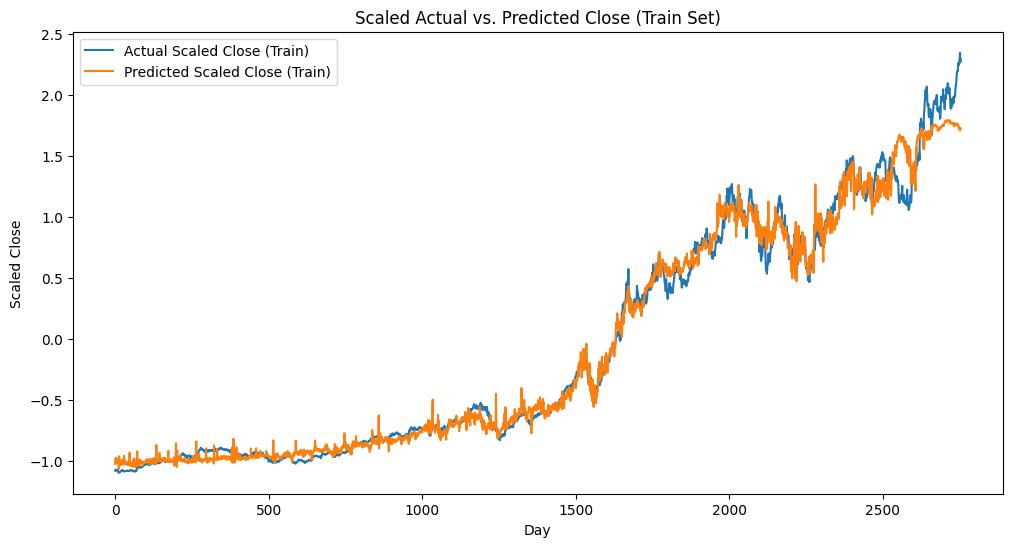

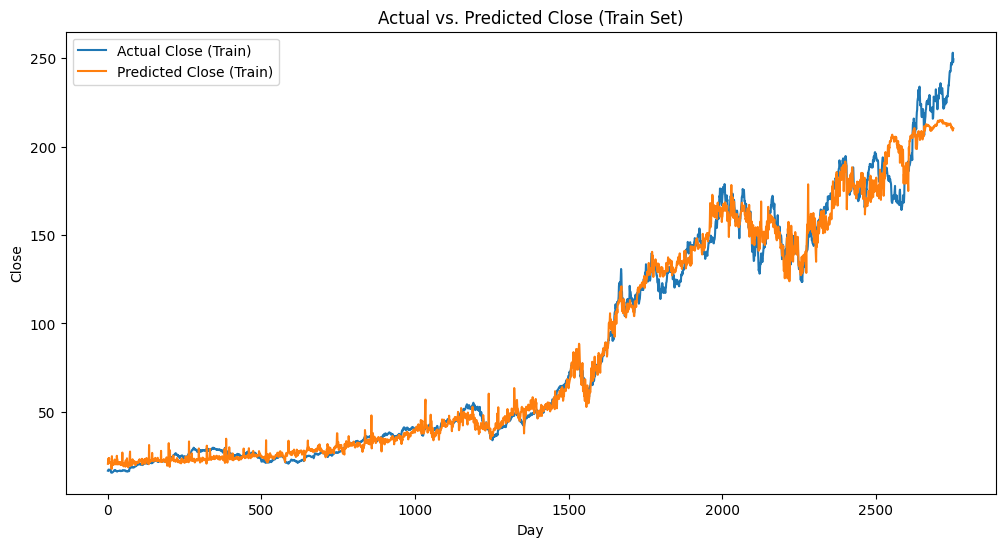

Training Set Metrics:
MSE: 62.4552
RMSE: 7.9029
MAE: 5.2935
MAPE: 7.6868%
R2: 0.9855


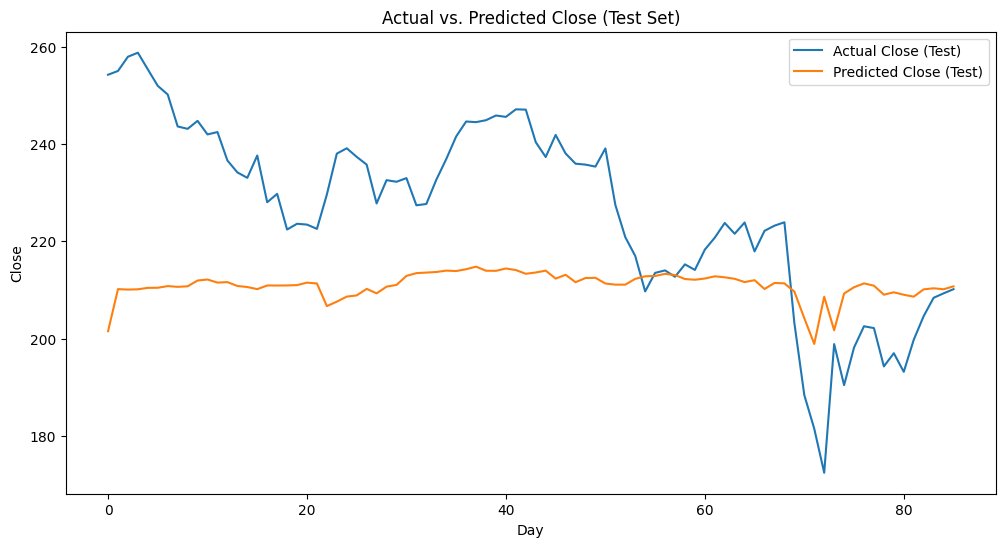


Testing Set Metrics:
MSE: 555.8264
RMSE: 23.5760
MAE: 19.9844
MAPE: 8.5740%
R2: -0.6137


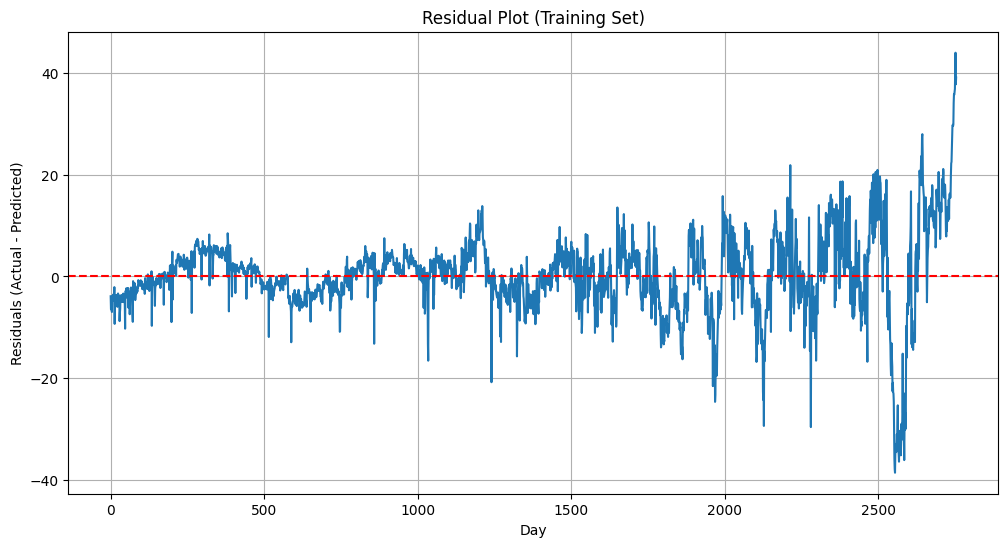

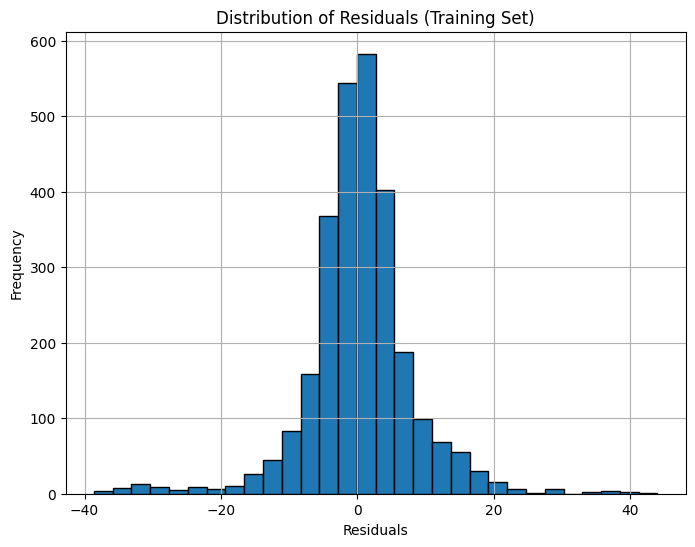

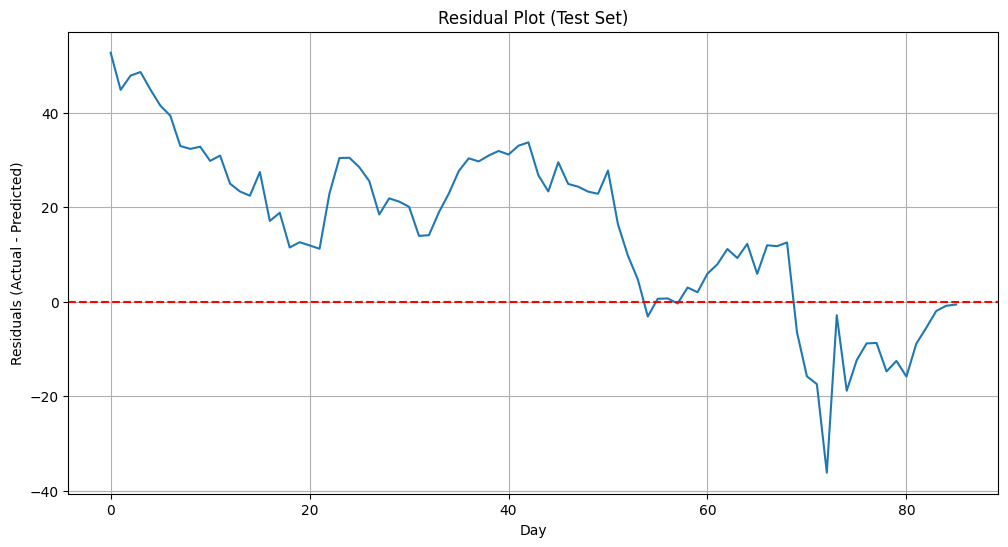

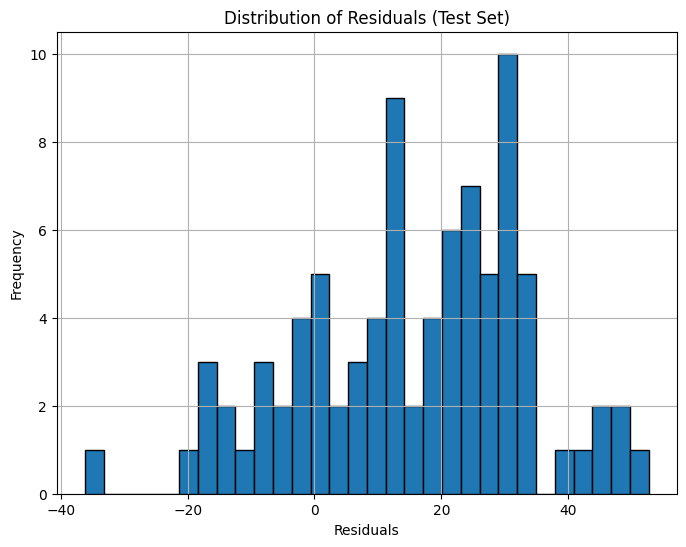


Performance Metrics:
        Set         MSE       RMSE        MAE  MAPE (%)        R2
0  Training   62.455246   7.902863   5.293532  7.686847  0.985502
1   Testing  555.826416  23.575971  19.984381  8.573987 -0.613690


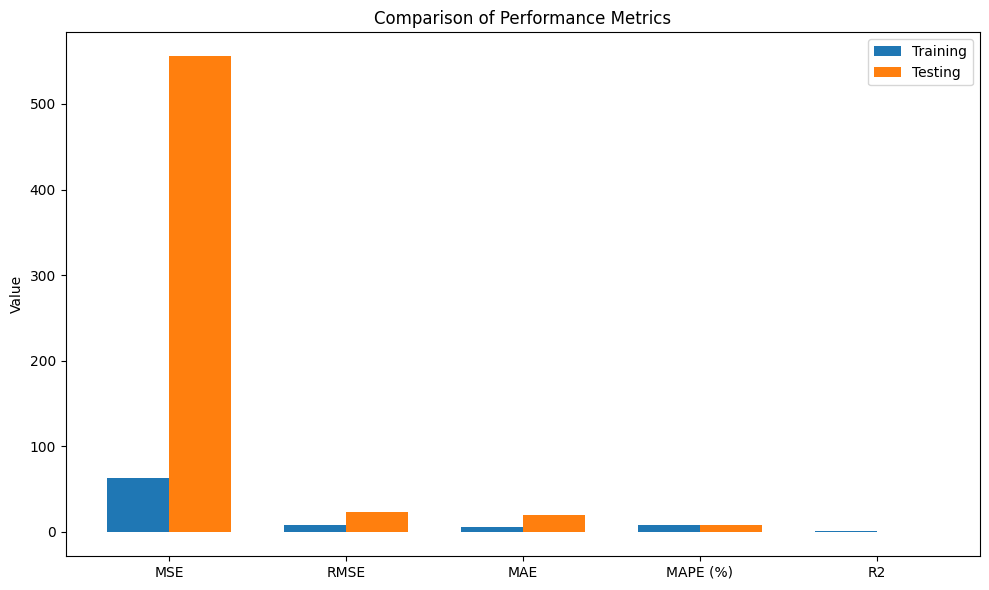

Epoch: 1
Batch 100, Loss: 0.012

Val Loss: 0.094
***************************************************

Epoch: 2
Batch 100, Loss: 0.011

Val Loss: 0.084
***************************************************

Epoch: 3
Batch 100, Loss: 0.011

Val Loss: 0.075
***************************************************

Epoch: 4
Batch 100, Loss: 0.010

Val Loss: 0.066
***************************************************

Epoch: 5
Batch 100, Loss: 0.009

Val Loss: 0.063
***************************************************

Epoch: 6
Batch 100, Loss: 0.008

Val Loss: 0.060
***************************************************

Epoch: 7
Batch 100, Loss: 0.007

Val Loss: 0.061
***************************************************

Epoch: 8
Batch 100, Loss: 0.006

Val Loss: 0.062
***************************************************

Epoch: 9
Batch 100, Loss: 0.006

Val Loss: 0.059
***************************************************

Epoch: 10
Batch 100, Loss: 0.006

Val Loss: 0.062
********************************

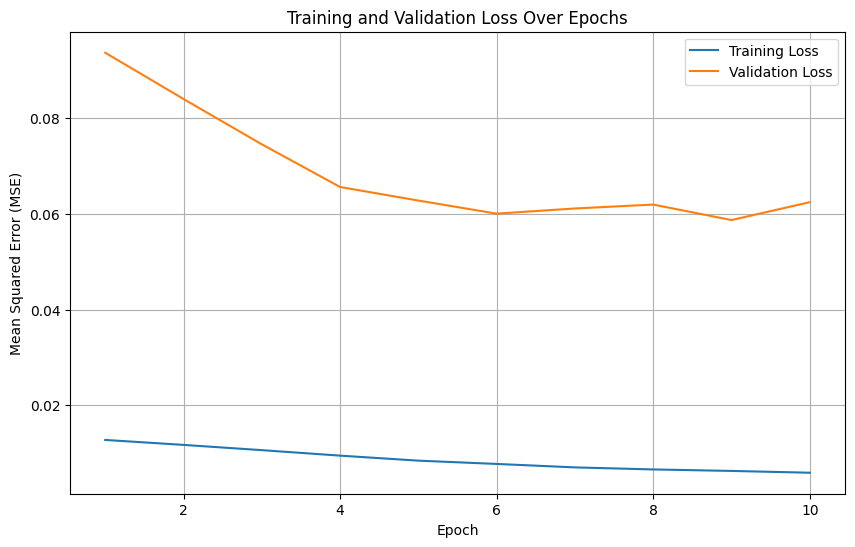

In [2]:
# Install necessary libraries (run this in your environment if you haven't already)
# pip install torch torchvision pandas numpy matplotlib scikit-learn

# Import pandas for data manipulation and analysis, especially for working with DataFrames.
import pandas as pd
# Import numpy for numerical operations, particularly for working with arrays.
import numpy as np
# Import matplotlib.pyplot for creating static, interactive, and animated visualizations in Python.
import matplotlib.pyplot as plt

# Import the main PyTorch library.
import torch
# Import the neural network module from PyTorch, which provides building blocks for neural networks.
import torch.nn as nn
# Import Dataset and DataLoader from PyTorch's utility for data loading and processing.
from torch.utils.data import Dataset, DataLoader
# Import StandardScaler from scikit-learn for standardizing features by removing the mean and scaling to unit variance.
from sklearn.preprocessing import StandardScaler
# Import deepcopy for creating independent copies of objects, preventing unintended modifications.
from copy import deepcopy as dc
# Import mean_squared_error, mean_absolute_error, and r2_score from scikit-learn for evaluating model performance.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load and Preprocess Data
# Load the dataset from a CSV file named 'clean_stock_data_with_time_index.csv' into a pandas DataFrame.
data = pd.read_csv('/content/clean_stock_data_with_time_index.csv')
# Convert the 'date' column to datetime objects. This is crucial for time series analysis as it allows for time-based operations.
data['date'] = pd.to_datetime(data['date'])

# 2. Prepare Data for LSTM
# Define a function to prepare the DataFrame for LSTM input by creating lagged features.
def prepare_dataframe_for_lstm(df, n_steps):
    # Create a deep copy of the input DataFrame to avoid modifying the original DataFrame.
    df = dc(df)
    # Set the 'date' column as the index of the DataFrame. This is important for time series data as it provides a temporal context.
    df.set_index('date', inplace=True)
    # Loop through a range of past time steps (from 1 to n_steps).
    for i in range(1, n_steps + 1):
        # Create a new column for each lagged time step. The values in this column are the 'close_AAPL' values shifted backward by 'i' steps.
        df[f'close_AAPL_t_{i}'] = df['close_AAPL'].shift(i)
    # Remove rows that contain NaN values. These NaN values are introduced by the shifting operation, particularly at the beginning of the DataFrame.
    df.dropna(inplace=True)
    # Return the DataFrame with the added lagged features.
    return df

# Define the number of past time steps (lookback period) the LSTM will use to make predictions. Here, it's set to 7 days.
lookback = 7
# Apply the 'prepare_dataframe_for_lstm' function to the loaded data to create the DataFrame with lagged 'close_AAPL' features.
shifted_df = prepare_dataframe_for_lstm(data, lookback)

# 3. Separate Features and Target
# Select the features for the LSTM model. Assuming the first 4 columns of the original DataFrame were 'open_AAPL', 'high_AAPL', 'low_AAPL', and 'close_AAPL',
# the lagged features start from the 5th column (index 4). All columns from index 4 onwards are considered as features.
X_shifted_df = shifted_df.iloc[:, 4:]
# Select the target variable, which is the 'close_AAPL' price at the current time step. This is the 4th column (index 3) of the 'shifted_df'.
y_shifted_df = shifted_df.iloc[:, 3:4]
# Convert the feature DataFrame to a NumPy array. NumPy arrays are efficient for numerical computations.
X_np = X_shifted_df.to_numpy()
# Convert the target DataFrame to a NumPy array.
y_np = y_shifted_df.to_numpy()

# 4. Scale Data
# Initialize a StandardScaler for the features. StandardScaler standardizes data by removing the mean and scaling to unit variance.
X_scaler = StandardScaler()
# Fit the scaler to the feature data (X_np) and then transform it. Fitting learns the mean and standard deviation from the training data,
# and transforming applies the scaling. It's crucial to fit only on the training data to prevent data leakage.
X_np_scaled = X_scaler.fit_transform(X_np)
# Initialize a StandardScaler for the target variable (y).
y_scaler = StandardScaler()
# Fit the scaler to the target data (y_np) and then transform it.
y_np_scaled = y_scaler.fit_transform(y_np)

# 5. Reshape and Flip
# Create a deep copy of the scaled feature array.
X = dc(np.flip(X_np_scaled, axis=1))
# Create a deep copy of the scaled target array.
y = dc(y_np_scaled)
# Note: Flipping the features along axis=1 might have been intended to process the most recent past data first.
# However, with 'batch_first=True' in the LSTM layer, the order of the sequence is typically handled correctly without explicit flipping.

# 6. Split into Train and Test Sets
# Define the index to split the data into training and testing sets. Here, 97% of the data will be used for training.
split_index = int(len(X) * 0.97)
# Split the scaled features into training and testing sets based on the calculated index.
X_train, X_test = X[:split_index], X[split_index:]
# Split the scaled target into training and testing sets.
y_train, y_test = y[:split_index], y[split_index:]

# 7. Adjust Features for LSTM Input Shape if necessary
# This loop ensures that the number of feature columns in the training and testing sets is a multiple of the 'lookback' period.
# This adjustment might be needed if the original number of features wasn't perfectly divisible by 'lookback'.
while X_train.shape[1] % lookback != 0:
    # Remove the last feature column from both the training and testing sets until the condition is met.
    X_train = X_train[:, :-1]
    X_test = X_test[:, :-1]
# Calculate the number of features per time step for the LSTM input. This is the total number of feature columns divided by the 'lookback' period.
num_features = X_train.shape[1] // lookback

# 8. Reshape for LSTM
# Reshape the training features to the expected input shape of the LSTM: (batch_size, sequence_length, input_size).
# Here, -1 infers the batch size, 'lookback' is the sequence length (number of time steps), and 'num_features' is the number of features at each time step.
X_train = X_train.reshape(-1, lookback, num_features)
# Reshape the testing features similarly.
X_test = X_test.reshape(-1, lookback, num_features)
# Reshape the training target to (batch_size, 1).
y_train = y_train.reshape((-1, 1))
# Reshape the testing target similarly.
y_test = y_test.reshape((-1, 1))

# 9. Convert to PyTorch Tensors
# Convert the NumPy arrays of the training features to PyTorch tensors with a float data type.
X_train = torch.tensor(X_train).float()
# Convert the NumPy array of the training target to a PyTorch tensor with a float data type.
y_train = torch.tensor(y_train).float()
# Convert the NumPy array of the testing features to a PyTorch tensor with a float data type.
X_test = torch.tensor(X_test).float()
# Convert the NumPy array of the testing target to a PyTorch tensor with a float data type.
y_test = torch.tensor(y_test).float()

# 10. Create Dataset and DataLoader
# Define a custom PyTorch Dataset class for time series data.
class TimeSeriesDataset(Dataset):
    # Constructor to initialize the dataset with features (X) and target (y).
    def __init__(self, X, y):
        self.X = X
        self.y = y

    # Method to return the total number of samples in the dataset. This is required by the DataLoader.
    def __len__(self):
        return len(self.X)

    # Method to get a single sample (feature and target) at a given index. This is required by the DataLoader.
    def __getitem__(self, i):
        return self.X[i], self.y[i]

# Create an instance of the TimeSeriesDataset for the training data.
train_dataset = TimeSeriesDataset(X_train, y_train)
# Create an instance of the TimeSeriesDataset for the testing data.
test_dataset = TimeSeriesDataset(X_test, y_test)

# Define the batch size for training and testing. This determines the number of samples processed in each iteration.
batch_size = 16
# Create a DataLoader for the training dataset. It shuffles the data for each epoch to improve training.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# Create a DataLoader for the testing dataset. Shuffling is usually not needed for evaluation.
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 11. Define LSTM Model
# Determine the device to use for training. It will use CUDA (GPU) if available, otherwise it will fall back to the CPU.
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Define the LSTM neural network model as a subclass of nn.Module.
class LSTM(nn.Module):
    # Constructor to initialize the layers of the LSTM.
    def __init__(self, input_size, hidden_size, num_stacked_layers):
        # Call the constructor of the parent class (nn.Module).
        super().__init__()
        # Define the number of hidden units in the LSTM layer. The hidden size determines the capacity of the LSTM to learn complex patterns.
        self.hidden_size = hidden_size
        # Define the number of LSTM layers to stack on top of each other. More layers can help the model learn more complex temporal dependencies.
        self.num_stacked_layers = num_stacked_layers
        # Define the LSTM layer itself.
        # input_size: The number of features at each time step.
        # hidden_size: The number of hidden units in the LSTM.
        # num_stacked_layers: The number of LSTM layers stacked.
        # batch_first=True: If True, the input and output tensors are provided as (batch, seq, feature) instead of (seq, batch, feature).
        self.lstm = nn.LSTM(input_size, hidden_size, num_stacked_layers, batch_first=True)
        # Define the fully connected (linear) layer that maps the output of the LSTM to the final prediction (a single value, the predicted close price).
        self.fc = nn.Linear(hidden_size, 1)

    # Forward pass of the LSTM model. This defines how the input data flows through the network.
    def forward(self, x):
        # Get the batch size of the input tensor.
        batch_size = x.size(0)
        # Initialize the hidden state h0 for the LSTM. It has dimensions (num_layers, batch_size, hidden_size).
        # It's initialized to zeros and moved to the specified device.
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        # Initialize the cell state c0 for the LSTM. It has the same dimensions as h0.
        # It's also initialized to zeros and moved to the device.
        c0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(device)
        # Pass the input sequence x and the initial hidden and cell states to the LSTM layer.
        # 'out' will contain the output features from the last layer of the LSTM for each time step in the sequence.
        # '_' contains the final hidden and cell states after processing the entire sequence.
        out, _ = self.lstm(x, (h0, c0))
        # Pass the output of the last time step of the LSTM sequence to the fully connected layer.
        # out[:, -1, :] selects the output of the last time step for all batches and all hidden units.
        out = self.fc(out[:, -1, :])
        # Return the output of the fully connected layer, which is the model's prediction.
        return out

# Instantiate the LSTM model.
# input_size is set to 'num_features', which is the number of features per time step.
# hidden_size is set to 4, which is the number of hidden units in the LSTM layer (this can be tuned).
# num_stacked_layers is set to 1, meaning there is one LSTM layer (this can also be tuned).
model = LSTM(num_features, 4, 1)
# Move the model's parameters to the specified device (GPU if available).
model.to(device)

# 12. Train and Evaluate
# Define the learning rate for the optimizer. This controls the step size during gradient descent.
learning_rate = 0.001
# Define the number of training epochs. An epoch is one complete pass through the entire training dataset.
num_epochs = 10
# Define the loss function. Mean Squared Error (MSE) is commonly used for regression tasks.
loss_function = nn.MSELoss()
# Define the optimizer (Adam). Adam is a popular optimization algorithm that adapts the learning rate for each parameter.
model_parameters = model.parameters()
optimizer = torch.optim.Adam(model_parameters, lr=learning_rate)

# Function to train the model for one epoch.
def train_one_epoch(epoch):
    # Set the model to training mode. This enables dropout and batch normalization (if used in the model).
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    # Initialize the running loss for the epoch. This will accumulate the loss over all batches.
    running_loss = 0.0
    # Iterate over the batches of the training data provided by the train_loader.
    for batch_index, batch in enumerate(train_loader):
        # Move the input features (x_batch) and target values (y_batch) of the current batch to the specified device.
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)
        # Forward pass: pass the input batch through the model to get the predictions.
        output = model(x_batch)
        # Calculate the loss between the model's output and the actual target values using the defined loss function.
        loss = loss_function(output, y_batch)
        # Accumulate the loss for the current batch to the running loss.
        running_loss += loss.item()
        # Zero the gradients of all model parameters. This is important before computing gradients for the current batch.
        optimizer.zero_grad()
        # Backward pass: compute the gradients of the loss with respect to the model's parameters.
        loss.backward()
        # Update the model's parameters based on the computed gradients using the optimizer.
        optimizer.step()
        # Print the average loss for every 100 batches to monitor training progress.
        if batch_index % 100 == 99:
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index + 1, avg_loss_across_batches))
            running_loss = 0.0
    print()

# Function to evaluate the model on the validation/test set for one epoch.
def validate_one_epoch():
    # Set the model to evaluation mode. This disables dropout and batch normalization, ensuring consistent predictions.
    model.train(False)
    # Initialize the running loss for the validation/test set.
    running_loss = 0.0
    # Iterate over the batches of the test data provided by the test_loader.
    for batch_index, batch in enumerate(test_loader):
        # Move the input features and target values of the current batch to the device.
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)
        # Disable gradient calculation during evaluation to save memory and time, as we are not updating model parameters.
        with torch.no_grad():
            # Forward pass: get the model's predictions for the input batch.
            output = model(x_batch)
            # Calculate the loss between the predictions and the actual targets.
            loss = loss_function(output, y_batch)
            # Accumulate the loss.
            running_loss += loss.item()
    # Calculate the average loss over all batches in the test loader.
    avg_loss_across_batches = running_loss / len(test_loader)
    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

# Train the model for the specified number of epochs.
for epoch in range(num_epochs):
    train_one_epoch(epoch)
    validate_one_epoch()

# Evaluation on the training set (before inverse transform)
with torch.no_grad():
    predicted_scaled_train = model(X_train.to(device)).to('cpu').numpy()

plt.figure(figsize=(12, 6))
plt.plot(y_train.cpu().numpy(), label='Actual Scaled Close (Train)')
plt.plot(predicted_scaled_train, label='Predicted Scaled Close (Train)')
plt.xlabel('Day')
plt.ylabel('Scaled Close')
plt.legend()
plt.title('Scaled Actual vs. Predicted Close (Train Set)')
plt.show()

# Plotting and Evaluation for Training Set (Inverse Transformed)
with torch.no_grad():
    predicted_scaled_train = model(X_train.to(device)).to('cpu').numpy()

# Inverse transform the predicted scaled values using the y_scaler to get the predictions in the original scale.
predicted_train = y_scaler.inverse_transform(predicted_scaled_train)
# Inverse transform the actual scaled training values using the y_scaler to get them in the original scale.
actual_train = y_scaler.inverse_transform(y_train.cpu().numpy())

plt.figure(figsize=(12, 6))
plt.plot(actual_train, label='Actual Close (Train)')
plt.plot(predicted_train, label='Predicted Close (Train)')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.title('Actual vs. Predicted Close (Train Set)')
plt.show()

# Evaluation Metrics for Training Set
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate the Mean Squared Error (MSE) between the actual and predicted values on the training set.
mse_train = mean_squared_error(actual_train, predicted_train)
# Calculate the Root Mean Squared Error (RMSE), which is the square root of the MSE. It provides an error metric in the same units as the target variable.
rmse_train = np.sqrt(mse_train)
# Calculate the Mean Absolute Error (MAE), which is the average of the absolute differences between the actual and predicted values.
mae_train = mean_absolute_error(actual_train, predicted_train)
# Calculate the R-squared (R²) score, which represents the proportion of the variance in the dependent variable that is predictable from the independent variables.
r2_train = r2_score(actual_train, predicted_train)

# Calculate MAPE (Mean Absolute Percentage Error)
def mean_absolute_percentage_error(y_true, y_pred):
    # Convert true and predicted values to NumPy arrays.
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Calculate the mean of the absolute percentage errors. Add a small epsilon to the denominator to avoid division by zero.
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Calculate the Mean Absolute Percentage Error on the training set.
mape_train = mean_absolute_percentage_error(actual_train, predicted_train)

print("Training Set Metrics:")
print(f"MSE: {mse_train:.4f}")
print(f"RMSE: {rmse_train:.4f}")
print(f"MAE: {mae_train:.4f}")
print(f"MAPE: {mape_train:.4f}%")
print(f"R2: {r2_train:.4f}")

# Plotting and Evaluation for Test Set (Inverse Transformed)
with torch.no_grad():
    predicted_scaled_test = model(X_test.to(device)).detach().cpu().numpy()

# Inverse transform the predicted scaled test values using the y_scaler.
predicted_test = y_scaler.inverse_transform(predicted_scaled_test)
# Inverse transform the actual scaled test values using the y_scaler.
actual_test = y_scaler.inverse_transform(y_test.cpu().numpy())

plt.figure(figsize=(12, 6))
plt.plot(actual_test, label='Actual Close (Test)')
plt.plot(predicted_test, label='Predicted Close (Test)')
plt.xlabel('Day')
plt.ylabel('Close')
plt.legend()
plt.title('Actual vs. Predicted Close (Test Set)')
plt.show()

# Evaluation Metrics for Test Set
# Calculate the Mean Squared Error (MSE) for the test set.
mse_test = mean_squared_error(actual_test, predicted_test)
# Calculate the Root Mean Squared Error (RMSE) for the test set.
rmse_test = np.sqrt(mse_test)
# Calculate the Mean Absolute Error (MAE) for the test set.
mae_test = mean_absolute_error(actual_test, predicted_test)
# Calculate the R-squared (R²) score for the test set.
r2_test = r2_score(actual_test, predicted_test)
# Calculate the Mean Absolute Percentage Error (MAPE) for the test set.
mape_test = mean_absolute_percentage_error(actual_test, predicted_test)

print("\nTesting Set Metrics:")
print(f"MSE: {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")
print(f"MAPE: {mape_test:.4f}%")
print(f"R2: {r2_test:.4f}")

# Error Analysis and Plots

# ---------------------- Training Set Error Analysis ----------------------

# Calculate residuals (errors) for the training set by subtracting the predicted values from the actual values.
train_residuals = actual_train - predicted_train

# Plot the residuals for the training set over time.
plt.figure(figsize=(12, 6))
plt.plot(train_residuals)
plt.title('Residual Plot (Training Set)')
plt.xlabel('Day')
plt.ylabel('Residuals (Actual - Predicted)')
plt.axhline(y=0, color='r', linestyle='--')  # Add a horizontal line at zero to visualize the center of the errors.
plt.grid(True)
plt.show()

# Plot the distribution of residuals for the training set using a histogram.
plt.figure(figsize=(8, 6))
plt.hist(train_residuals, bins=30, edgecolor='black')
plt.title('Distribution of Residuals (Training Set)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# ---------------------- Test Set Error Analysis ----------------------

# Calculate residuals for the test set.
test_residuals = actual_test - predicted_test

# Plot the residuals for the test set over time.
plt.figure(figsize=(12, 6))
plt.plot(test_residuals)
plt.title('Residual Plot (Test Set)')
plt.xlabel('Day')
plt.ylabel('Residuals (Actual - Predicted)')
plt.axhline(y=0, color='r', linestyle='--')
plt.grid(True)
plt.show()

# Plot the distribution of residuals for the test set.
plt.figure(figsize=(8, 6))
plt.hist(test_residuals, bins=30, edgecolor='black')
plt.title('Distribution of Residuals (Test Set)')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# ---------------------- Performance Metrics Table ----------------------

import pandas as pd

# Create a pandas DataFrame to display the performance metrics for both the training and testing sets in a table format.
performance_df = pd.DataFrame({
    'Set': ['Training', 'Testing'],
    'MSE': [mse_train, mse_test],
    'RMSE': [rmse_train, rmse_test],
    'MAE': [mae_train, mae_test],
    'MAPE (%)': [mape_train, mape_test],
    'R2': [r2_train, r2_test]
})

print("\nPerformance Metrics:")
print(performance_df)

# ---------------------- Performance Metrics Plots ----------------------

# Define the list of performance metrics to be plotted.
metrics = ['MSE', 'RMSE', 'MAE', 'MAPE (%)', 'R2']
# Extract the training set metric values from the 'performance_df'.
train_values = performance_df[performance_df['Set'] == 'Training'][metrics].values.flatten()
# Extract the testing set metric values.
test_values = performance_df[performance_df['Set'] == 'Testing'][metrics].values.flatten()

# Set the x-axis positions for the bars.
x = np.arange(len(metrics))
# Define the width of the bars.
width = 0.35

# Create a figure and an axes object for the plot.
fig, ax = plt.subplots(figsize=(10, 6))
# Create bar plots for the training set metrics.
rects1 = ax.bar(x - width/2, train_values, width, label='Training')
# Create bar plots for the testing set metrics, offset by 'width' to place them next to the training bars.
rects2 = ax.bar(x + width/2, test_values, width, label='Testing')

# Set the y-axis label.
ax.set_ylabel('Value')
# Set the title of the plot.
ax.set_title('Comparison of Performance Metrics')
# Set the x-axis tick positions.
ax.set_xticks(x)
# Set the x-axis tick labels to the metric names.
ax.set_xticklabels(metrics)
# Add a legend to the plot to distinguish between training and testing metrics.
ax.legend()

# Adjust the layout to prevent labels from overlapping.
fig.tight_layout()
# Display the plot.
plt.show()

# ---------------------- Loss Function and Epoch Trend ----------------------

# To visualize the loss function trend over epochs, we need to store the loss values
# during training and validation. Let's modify the training loop to do this.

train_losses = []
val_losses = []

def train_one_epoch_with_logging(epoch):
    model.train(True)
    print(f'Epoch: {epoch + 1}')
    running_loss = 0.0
    epoch_loss = []
    for batch_index, batch in enumerate(train_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)
        output = model(x_batch)
        loss = loss_function(output, y_batch)
        running_loss += loss.item()
        epoch_loss.append(loss.item())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch_index % 100 == 99:
            avg_loss_across_batches = running_loss / 100
            print('Batch {0}, Loss: {1:.3f}'.format(batch_index + 1, avg_loss_across_batches))
            running_loss = 0.0
    train_losses.append(np.mean(epoch_loss))
    print()

def validate_one_epoch_with_logging():
    model.train(False)
    running_loss = 0.0
    epoch_loss = []
    for batch_index, batch in enumerate(test_loader):
        x_batch, y_batch = batch[0].to(device), batch[1].to(device)
        with torch.no_grad():
            output = model(x_batch)
            loss = loss_function(output, y_batch)
            running_loss += loss.item()
            epoch_loss.append(loss.item())
    val_losses.append(np.mean(epoch_loss))
    avg_loss_across_batches = running_loss / len(test_loader)
    print('Val Loss: {0:.3f}'.format(avg_loss_across_batches))
    print('***************************************************')
    print()

# Re-run the training loop with loss logging
train_losses = []
val_losses = []
num_epochs = 10  # Reset the number of epochs if you changed it

for epoch in range(num_epochs):
    train_one_epoch_with_logging(epoch)
    validate_one_epoch_with_logging()

# Plot the training and validation loss over epochs
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, label='Training Loss')
plt.plot(range(1, num_epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# The main loss function used is Mean Squared Error (MSE), which is printed
# during the training and validation phases. The final MSE on the test set
# is also included in the performance metrics table and plots. The epoch trend
# plot visualizes how the MSE evolved over the training process for both the
# training and validation datasets.

In [3]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error

# Assume 'model', 'X_test', and 'y_test' are already defined and loaded
model.eval()  # Set model to evaluation mode
device = next(model.parameters()).device

original_predictions = model(X_test.to(device)).detach().cpu().numpy()
original_mse = mean_squared_error(y_test.cpu().numpy(), original_predictions)
print(f"Original Test MSE: {original_mse:.4f}")

feature_importances = {}
num_features = X_test.shape[2]  # Number of features per time step

for feature_index in range(num_features):
    perturbed_X_test = X_test.clone()
    # Perturb the values of the current feature (e.g., set to mean)
    mean_val = X_test[:, :, feature_index].mean()
    perturbed_X_test[:, :, feature_index] = mean_val

    with torch.no_grad():
        perturbed_predictions = model(perturbed_X_test.to(device)).detach().cpu().numpy()

    perturbed_mse = mean_squared_error(y_test.cpu().numpy(), perturbed_predictions)
    importance = np.abs(original_mse - perturbed_mse)
    feature_importances[f"feature_{feature_index}"] = importance

# Sort features by importance
sorted_importances = sorted(feature_importances.items(), key=lambda item: item[1], reverse=True)
print("\nFeature Importances (Sensitivity Analysis - Higher is more important):")
for feature, importance in sorted_importances:
    print(f"{feature}: {importance:.4f}")

Original Test MSE: 0.0580

Feature Importances (Sensitivity Analysis - Higher is more important):
feature_17: 0.0097
feature_5: 0.0080
feature_14: 0.0055
feature_4: 0.0049
feature_11: 0.0049
feature_18: 0.0047
feature_2: 0.0046
feature_13: 0.0046
feature_1: 0.0033
feature_15: 0.0033
feature_22: 0.0029
feature_7: 0.0027
feature_23: 0.0023
feature_12: 0.0023
feature_24: 0.0022
feature_6: 0.0020
feature_20: 0.0018
feature_3: 0.0013
feature_8: 0.0011
feature_16: 0.0011
feature_25: 0.0009
feature_10: 0.0008
feature_0: 0.0007
feature_9: 0.0006
feature_19: 0.0004
feature_21: 0.0000


In [5]:
data.iloc[: , 15:19]

,volume_GOOGL,open_AMZN,high_AMZN,low_AMZN
0,72783144,19.940001,19.968000,19.701000
1,66601332,19.914499,20.135500,19.811001
2,70701228,19.792500,19.850000,19.421000
3,102001896,19.752001,19.923500,19.714500
4,89610300,19.923500,20.150000,19.802000
...,...,...,...,...
2842,26971800,169.850006,176.779999,169.350006
2843,31128800,183.449997,187.380005,180.190002
2844,45894000,180.919998,186.740005,180.179993
2845,56034000,187.619995,189.940002,185.490005


In [7]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from copy import deepcopy as dc

# Assuming you have your 'shifted_df' created as in your original code
# (DataFrame with lagged features and the target 'close_AAPL')

# Separate features and target
X_shifted_df = shifted_df.iloc[:, 4:]
y_shifted_df = shifted_df.iloc[:, 3]  # Target as a Series for correlation

# Calculate the correlation between each feature and the target
correlations = X_shifted_df.corrwith(y_shifted_df).abs().sort_values(ascending=False)

print("Correlation with Target (Absolute Value):")
print(correlations)

# You can select the top N features based on correlation
top_n_correlation = correlations.head(50)
print("\nTop 50 Features by Correlation:")
print(top_n_correlation.index.tolist())

Correlation with Target (Absolute Value):
close_AAPL_t_1      0.999547
close_AAPL_t_2      0.999103
close_AAPL_t_3      0.998639
close_AAPL_t_4      0.998217
close_AAPL_t_5      0.997826
                      ...   
volume_ADBE         0.074538
volume_JNJ          0.071810
volume_UNH          0.028275
volume_TSLA         0.014742
20Y_Treasury_ETF    0.006415
Length: 184, dtype: float64

Top 50 Features by Correlation:
['close_AAPL_t_1', 'close_AAPL_t_2', 'close_AAPL_t_3', 'close_AAPL_t_4', 'close_AAPL_t_5', 'close_AAPL_t_6', 'close_AAPL_t_7', 'Tech_Sector_ETF', 'high_MSFT', 'close_MSFT', 'open_MSFT', 'low_MSFT', 'Nasdaq100_ETF', 'S&P500_Index', 'Healthcare_Sector_ETF', 'high_GOOGL', 'close_GOOGL', 'open_GOOGL', 'NASDAQ_Composite', 'low_GOOGL', 'low_PG', 'close_PG', 'open_PG', 'high_PG', 'ConsumerStaples_ETF', 'Materials_Sector_ETF', 'high_HD', 'close_HD', 'open_HD', 'low_HD', 'Industrial_Sector_ETF', 'Semiconductor_ETF', 'high_UNH', 'close_UNH', 'low_UNH', 'open_UNH', 'Dow_Jones_Index'

In [9]:
from sklearn.feature_selection import mutual_info_regression

# Assuming you have your 'shifted_df' created
X_shifted_df = shifted_df.iloc[:, 4:]  # Keep as DataFrame
y_shifted_df = shifted_df.iloc[:, 3].values

# It's often recommended to scale features before calculating mutual information
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_shifted_df)

# Calculate mutual information
mutual_info = mutual_info_regression(X_scaled, y_shifted_df, random_state=42)

# Create a Series of mutual information values with feature names
mutual_info_series = pd.Series(mutual_info, index=X_shifted_df.columns).sort_values(ascending=False)

print("\nMutual Information with Target:")
print(mutual_info_series)

# Select the top N features based on mutual information
top_n_mutual_info = mutual_info_series.head(50)
print("\nTop 50 Features by Mutual Information:")
print(top_n_mutual_info.index.tolist())


Mutual Information with Target:
close_AAPL_t_1     3.544916
close_AAPL_t_2     3.209755
close_AAPL_t_3     3.029268
close_AAPL_t_4     2.919617
Tech_Sector_ETF    2.874558
                     ...   
volume_PEP         0.103845
volume_GOOGL       0.099330
volume_UNH         0.084470
volume_PG          0.081798
volume_JNJ         0.072252
Length: 184, dtype: float64

Top 50 Features by Mutual Information:
['close_AAPL_t_1', 'close_AAPL_t_2', 'close_AAPL_t_3', 'close_AAPL_t_4', 'Tech_Sector_ETF', 'close_AAPL_t_5', 'Nasdaq100_ETF', 'close_AAPL_t_6', 'close_AAPL_t_7', 'close_MSFT', 'high_MSFT', 'low_MSFT', 'NASDAQ_Composite', 'open_MSFT', 'S&P500_Index', 'Semiconductor_ETF', 'close_NVDA', 'high_NVDA', 'low_NVDA', 'Tech_Software_Sector_ETF', 'close_GOOGL', 'high_GOOGL', 'open_NVDA', 'high_HD', 'low_HD', 'high_MA', 'low_GOOGL', 'high_V', 'close_HD', 'close_V', 'close_MA', 'open_GOOGL', 'low_V', 'open_HD', 'low_MA', 'ConsumerDiscretionary_ETF', 'Healthcare_Sector_ETF', 'high_UNH', 'open_MA',